# Temporal-Difference Learning — Experiments

Validates the core claims of `temporal-difference-learning.tex`:

1. **TD vs MC (random walk)**: on the same data, TD(0)'s value estimates beat Monte Carlo (the bias–variance trade-off);
2. **n-step returns**: larger $n$ approaches MC (low bias, high variance); smaller $n$ leans on bootstrapping (high bias, low variance);
3. **on-policy vs off-policy (Cliff Walking)**: SARSA learns a conservative, safe policy; Q-Learning learns the optimum but is riskier during training.

Environments:
- **5-state random walk** (Sutton & Barto Example 6.2): states A–E, left terminal rewards 0, right terminal +1, $\gamma=1$;
- **CliffWalking-v0** (Gymnasium, Sutton & Barto Example 6.6): $4\times12$ cliff walking, ordinary steps $-1$, falling off the cliff $-100$ and back to the start.

Output figures:
- `fig1_random_walk_mc_vs_td.pdf`
- `fig2_nstep_bias_variance.pdf`
- `fig3_cliff_sarsa_vs_qlearning.pdf`

Estimated runtime: < 2 minutes (CPU).

In [ ]:
BREAKRL_CHAPTER = 'temporal-difference-learning'

import sys

if 'google.colab' in sys.modules:
    import runpy
    import urllib.request
    from pathlib import Path

    _setup = Path('/content/_breakrl_colab_setup.py')
    _req = urllib.request.Request(
        'https://raw.githubusercontent.com/Powfu-zwx/BreakRL/main/scripts/colab_setup.py' + '?v=2',
        headers={'Cache-Control': 'no-cache'},
    )
    _setup.write_bytes(urllib.request.urlopen(_req).read())
    runpy.run_path(str(_setup))['setup'](BREAKRL_CHAPTER)


In [1]:
%matplotlib inline
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ── Academic style ──────────────────────────────────────────────
mpl.rcParams.update({
    'font.family':        'serif',
    'font.serif':         ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size':          11,
    'axes.labelsize':     12,
    'axes.titlesize':     13,
    'axes.titleweight':   'bold',
    'axes.titlepad':      10,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'legend.framealpha':  0.9,
    'legend.edgecolor':   '#CCCCCC',
    'figure.dpi':         150,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.color':         '#DDDDDD',
    'grid.linestyle':     '--',
    'grid.linewidth':     0.6,
    'lines.linewidth':    2.0,
    'savefig.bbox':       'tight',
    'pdf.fonttype':       42,
})

# Color palette (same as other chapters)
C_BLUE   = '#2166AC'
C_RED    = '#D6604D'
C_PURPLE = '#762A83'
C_GREEN  = '#4DAC26'
C_GRAY   = '#888888'

try:
    import gymnasium as gym
    GYM_BACKEND = 'gymnasium'
except ImportError:
    import gym
    GYM_BACKEND = 'gym'

OUTDIR = '.'

print(f'Setup complete (gym backend: {GYM_BACKEND}).')

Setup complete (gym backend: gymnasium).


---
## Figure 1 — Random walk: value estimates of TD(0) vs MC

Five non-terminal states A–E (numbered 1–5), one terminal on each side. Each step moves left/right with probability $0.5$; entering the right terminal gives $+1$, the left terminal $0$. True values $v(s)=s/6$.

MC and TD(0) run on **the same batch of trajectories** (fixed seed) with step sizes as in Sutton & Barto Figure 6.2 ($\alpha_{\text{TD}}=0.1$, $\alpha_{\text{MC}}=0.01$): MC must wait for whole episodes and needs a smaller step size to average returns; TD(0) corrects in place every step and tolerates a larger one, tracking the true values faster.

after   100 episodes: mean RMS over 100 runs  MC = 0.149   TD(0) = 0.062


after   200 episodes: mean RMS over 100 runs  MC = 0.070   TD(0) = 0.055


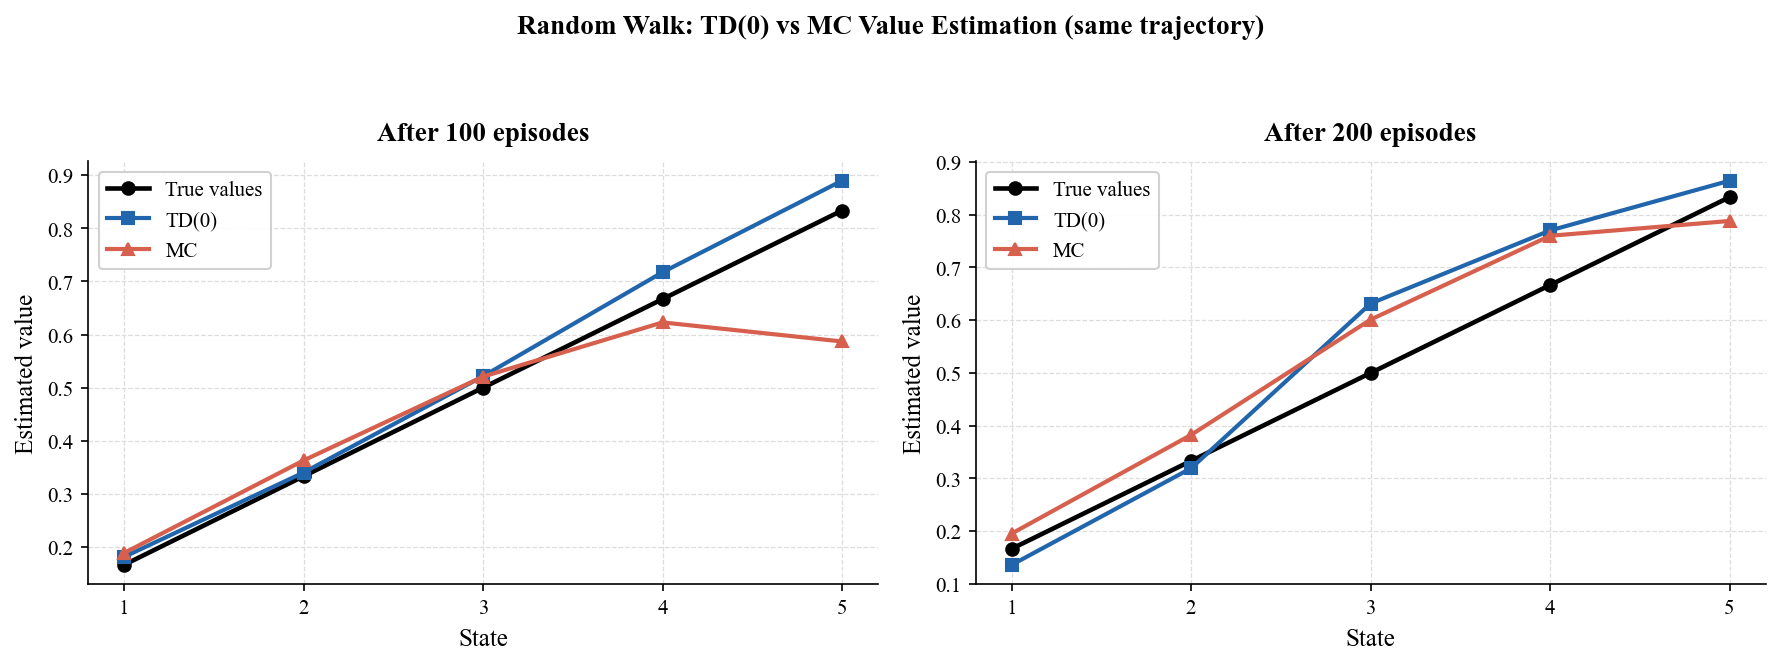

Saved fig1_random_walk_mc_vs_td.pdf


In [2]:
TRUE_V = np.array([1, 2, 3, 4, 5]) / 6.0        # 状态 1..5 的真实价值
GAMMA = 1.0
ALPHA_TD = 0.1     # TD(0) 步长
ALPHA_MC = 0.01    # MC 步长（Sutton & Barto 图 6.2 的设置）


def one_episode(rng):
    """从状态 3（C）出发跑一局，返回 (状态序列, 奖励序列)。"""
    s = 3
    states = [s]
    rewards = []
    while True:
        s = s + rng.choice([-1, 1])
        if s == 0:               # 左终点：奖励 0，结束
            rewards.append(0.0); break
        elif s == 6:             # 右终点：奖励 +1，结束
            rewards.append(1.0); break
        else:
            rewards.append(0.0)
            states.append(s)
    return states, rewards


def mc_predict(episodes, alpha, seed):
    """蒙特卡洛：跑完整局后用真实回报 G_t 增量更新 V(s) += α(G_t - V(s))。"""
    rng = np.random.default_rng(seed)
    V = np.zeros(7)
    for _ in range(episodes):
        states, rewards = one_episode(rng)
        G = 0.0
        for s, r in zip(reversed(states), reversed(rewards)):
            G = r + GAMMA * G
            V[s] += alpha * (G - V[s])
    return V


def td0_predict(episodes, alpha, seed):
    """TD(0)：每步用一步奖励 + 对下一步的当前估计更新 V(s) += α[R+γV(s')-V(s)]。"""
    rng = np.random.default_rng(seed)
    V = np.zeros(7)
    for _ in range(episodes):
        states, rewards = one_episode(rng)
        for t in range(len(rewards)):
            s = states[t]; ns = states[t + 1] if t + 1 < len(states) else None
            r = rewards[t]
            target = r if ns is None else r + GAMMA * V[ns]
            V[s] += alpha * (target - V[s])
    return V


def rms(V):
    return np.sqrt(np.mean((V[1:6] - TRUE_V) ** 2))


# 同一局轨迹（固定种子）的价值估计
SEED = 0
N_RUNS = 100
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, n_ep in zip(axes, (100, 200)):
    V_mc = mc_predict(n_ep, ALPHA_MC, SEED)
    V_td = td0_predict(n_ep, ALPHA_TD, SEED)
    x = np.arange(1, 6)
    ax.plot(x, TRUE_V, 'k-o', label='True values', linewidth=2.2)
    ax.plot(x, V_td[1:6], marker='s', color=C_BLUE, label='TD(0)')
    ax.plot(x, V_mc[1:6], marker='^', color=C_RED, label='MC')
    ax.set_xlabel('State')
    ax.set_ylabel('Estimated value')
    ax.set_title(f'After {n_ep} episodes')
    ax.set_xticks(x)
    ax.legend()
    # 100 局平均的个体 RMS（Sutton & Barto 的指标）
    mc_rms = np.mean([rms(mc_predict(n_ep, ALPHA_MC, s)) for s in range(N_RUNS)])
    td_rms = np.mean([rms(td0_predict(n_ep, ALPHA_TD, s)) for s in range(N_RUNS)])
    print(f'after {n_ep:5d} episodes: mean RMS over {N_RUNS} runs  '
          f'MC = {mc_rms:.3f}   TD(0) = {td_rms:.3f}')

fig.suptitle('Random Walk: TD(0) vs MC Value Estimation (same trajectory)',
             fontsize=13, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(f'{OUTDIR}/fig1_random_walk_mc_vs_td.pdf', bbox_inches='tight')
plt.show()

print('Saved fig1_random_walk_mc_vs_td.pdf')

---
## Figure 2 — n-step returns: the bias–variance trade-off

The n-step return $G_t^{(n)} = R_{t+1}+\gamma R_{t+2}+\cdots+\gamma^{n-1}R_{t+n}+\gamma^n V(S_{t+n})$ is a continuum between TD(0) ($n=1$, full bootstrapping) and MC ($n\to\infty$, none). RMS error over 100 episodes of the 5-state random walk under the same $\alpha=0.1$:

n=TD(0) (n=1)      final RMS = 0.0554


n=n-step (n=3)     final RMS = 0.0844


n=n-step (n=10)    final RMS = 0.1440


n=MC (n=$\infty$)  final RMS = 0.1666


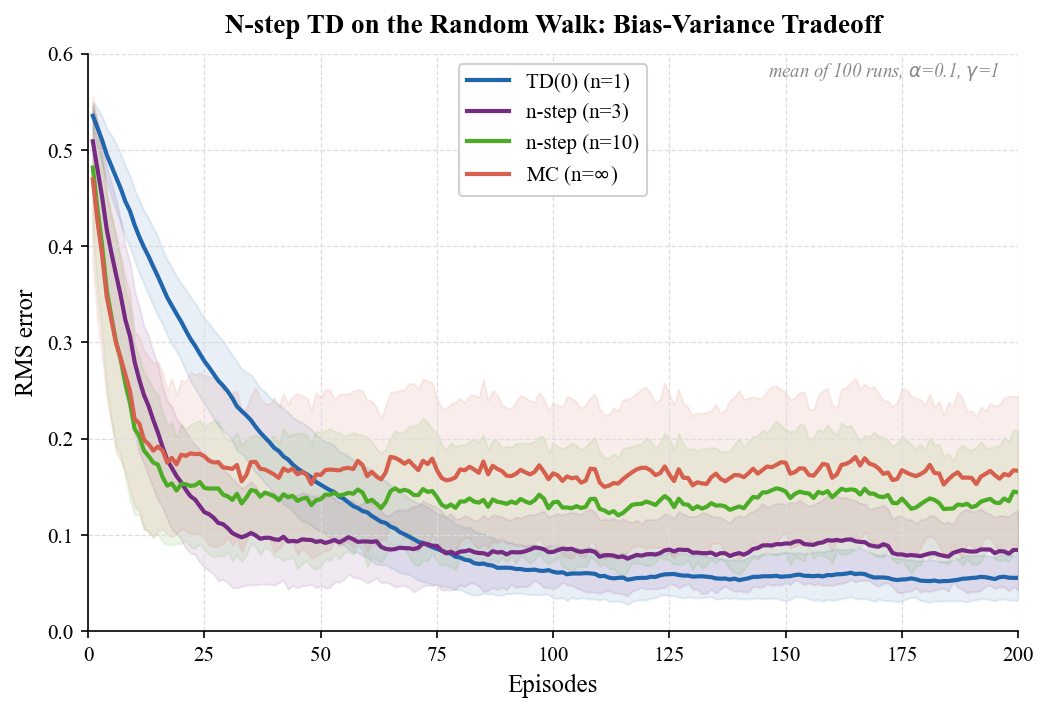

Saved fig2_nstep_bias_variance.pdf


In [3]:
def run_nstep_predict(n, n_episodes, alpha, seed):
    """n 步 TD 预测：目标为 G_t^{(n)}（n 个真实奖励 + 第 n 步处 bootstrap）。n 足够大时退化为 MC。"""
    rng = np.random.default_rng(seed)
    V = np.zeros(7)
    rms_curve = []
    for _ in range(n_episodes):
        states, rewards = one_episode(rng)
        T = len(rewards)
        for t in range(T):
            horizon = min(t + n, T)
            G = sum(GAMMA ** (k - t) * rewards[k] for k in range(t, horizon))
            if t + n < T:
                G += GAMMA ** n * V[states[t + n]]
            V[states[t]] += alpha * (G - V[states[t]])
        rms_curve.append(rms(V))
    return rms_curve


N_EP_MAX, N_RUNS2 = 200, 100
N_VALUES = [1, 3, 10, 10 ** 6]
NAMES = {1: 'TD(0) (n=1)', 3: 'n-step (n=3)', 10: 'n-step (n=10)', 10 ** 6: 'MC (n=$\\infty$)'}
STYLES = {1: C_BLUE, 3: C_PURPLE, 10: C_GREEN, 10 ** 6: C_RED}

curves = {}
for n in N_VALUES:
    rs = np.stack([run_nstep_predict(n, N_EP_MAX, ALPHA_TD, s) for s in range(N_RUNS2)])
    curves[n] = rs
    print(f'n={NAMES[n]:16s} final RMS = {rs.mean(axis=0)[-1]:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(1, N_EP_MAX + 1)
for n in N_VALUES:
    mean, std = curves[n].mean(axis=0), curves[n].std(axis=0)
    ax.plot(x, mean, label=NAMES[n], color=STYLES[n])
    ax.fill_between(x, mean - std, mean + std, alpha=0.10, color=STYLES[n])

ax.set_xlabel('Episodes')
ax.set_ylabel('RMS error')
ax.set_title('N-step TD on the Random Walk: Bias-Variance Tradeoff')
ax.set_xlim(0, N_EP_MAX)
ax.set_ylim(0, 0.6)
ax.legend()
ax.text(0.98, 0.96,
        f'mean of {N_RUNS2} runs, $\\alpha$={ALPHA_TD}, $\\gamma$=1',
        transform=ax.transAxes, ha='right', fontsize=9, color=C_GRAY, style='italic')
fig.savefig(f'{OUTDIR}/fig2_nstep_bias_variance.pdf', bbox_inches='tight')
plt.show()

print('Saved fig2_nstep_bias_variance.pdf')

---
## Figure 3 — Cliff Walking: SARSA vs Q-Learning

The $4\times12$ cliff: start bottom-left, goal bottom-right, the 10 middle cells of the bottom row are cliff. Ordinary steps $-1$; stepping on the cliff costs $-100$ and returns to the start. Parameters $\alpha=0.5$, $\varepsilon=0.1$, $\gamma=1$; x-axis episodes, y-axis per-episode cumulative reward (10-episode moving average).

- **SARSA (on-policy)** learns the $q_\pi$ of the $\varepsilon$-greedy policy and avoids hugging the cliff --- higher training rewards;
- **Q-Learning (off-policy)** learns the optimal greedy policy and falls off the cliff often during training due to random exploration --- lower training rewards, but a shorter final policy.

=== Cliff Walking: SARSA vs Q-Learning ===


SARSA      mean reward/episode (last 50) =  -25.58
Q-Learning mean reward/episode (last 50) =  -46.07


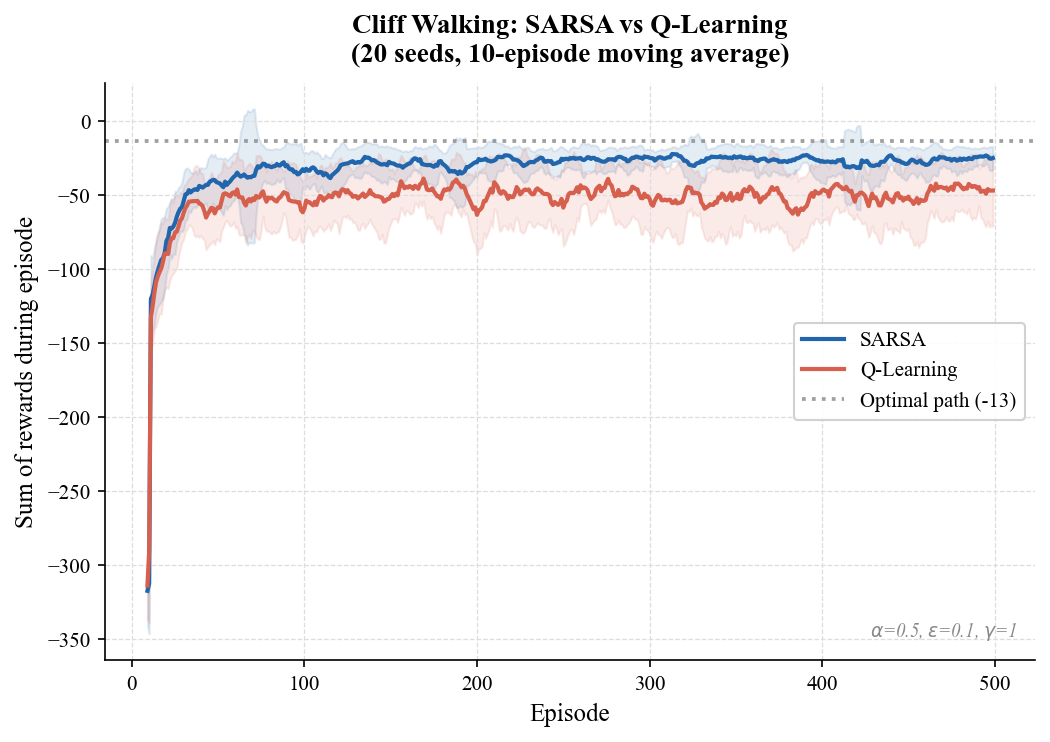

Saved fig3_cliff_sarsa_vs_qlearning.pdf


In [4]:
def run_sarsa(episodes=500, alpha=0.5, gamma=1.0, eps=0.1, seed=0):
    """on-policy：目标用“实际会选”的 A' 的 Q 值（含探索）。"""
    env = gym.make('CliffWalking-v0')
    if hasattr(env.action_space, 'seed'):
        env.action_space.seed(seed)
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    returns = []
    for _ in range(episodes):
        s, _ = env.reset()
        if rng.random() < eps:
            a = int(rng.integers(env.action_space.n))
        else:
            a = int(np.argmax(Q[s]))
        G, episode_done = 0.0, False
        while not episode_done:
            ns, r, terminated, truncated, _ = env.step(a)
            episode_done = terminated or truncated
            if terminated:
                target = r
                a_next = None
            else:
                if rng.random() < eps:
                    a_next = int(rng.integers(env.action_space.n))
                else:
                    a_next = int(np.argmax(Q[ns]))
                target = r + gamma * Q[ns, a_next]
            Q[s, a] += alpha * (target - Q[s, a])
            if not episode_done:
                s, a = ns, a_next
            G += r
        returns.append(G)
    env.close()
    return np.array(returns)


def run_qlearning(episodes=500, alpha=0.5, gamma=1.0, eps=0.1, seed=0):
    """off-policy：目标用 max_a' Q(s', a')，与实际如何探索无关。"""
    env = gym.make('CliffWalking-v0')
    if hasattr(env.action_space, 'seed'):
        env.action_space.seed(seed)
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    returns = []
    for _ in range(episodes):
        s, _ = env.reset()
        G, episode_done = 0.0, False
        while not episode_done:
            if rng.random() < eps:
                a = int(rng.integers(env.action_space.n))
            else:
                a = int(np.argmax(Q[s]))
            ns, r, terminated, truncated, _ = env.step(a)
            episode_done = terminated or truncated
            target = r if terminated else r + gamma * np.max(Q[ns])
            Q[s, a] += alpha * (target - Q[s, a])
            if not episode_done:
                s = ns
            G += r
        returns.append(G)
    env.close()
    return np.array(returns)


EPISODES, N_SEEDS = 500, 20
W = 10  # 滑动平均窗

print('=== Cliff Walking: SARSA vs Q-Learning ===')
sarsa = np.stack([run_sarsa(EPISODES, seed=s) for s in range(N_SEEDS)])
qlearn = np.stack([run_qlearning(EPISODES, seed=s) for s in range(N_SEEDS)])
print(f'SARSA      mean reward/episode (last 50) = {sarsa.mean(axis=0)[-50:].mean():7.2f}')
print(f'Q-Learning mean reward/episode (last 50) = {qlearn.mean(axis=0)[-50:].mean():7.2f}')


def smooth(x, w):
    k = np.ones(w) / w
    return np.convolve(x, k, mode='valid')


fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(W - 1, EPISODES)
for data, label, color in [(sarsa, 'SARSA', C_BLUE), (qlearn, 'Q-Learning', C_RED)]:
    sm = np.stack([smooth(row, W) for row in data])
    mean, std = sm.mean(axis=0), sm.std(axis=0)
    ax.plot(x, mean, label=label, color=color)
    ax.fill_between(x, mean - std, mean + std, alpha=0.12, color=color)

ax.axhline(-13, color=C_GRAY, linestyle=':', linewidth=1.8, alpha=0.8,
           label='Optimal path (-13)')
ax.set_xlabel('Episode')
ax.set_ylabel('Sum of rewards during episode')
ax.set_title('Cliff Walking: SARSA vs Q-Learning\n'
             f'({N_SEEDS} seeds, {W}-episode moving average)')
ax.legend()
ax.text(0.98, 0.04, f'$\\alpha$=0.5, $\\varepsilon$=0.1, $\\gamma$=1',
        transform=ax.transAxes, ha='right', fontsize=9, color=C_GRAY, style='italic')
fig.savefig(f'{OUTDIR}/fig3_cliff_sarsa_vs_qlearning.pdf', bbox_inches='tight')
plt.show()

print('Saved fig3_cliff_sarsa_vs_qlearning.pdf')

## Summary

- **TD(0)** updates with "one real reward plus the current estimate of the next step", without waiting for episode end; the price is a biased estimate, in exchange for much lower variance and faster convergence;
- **n-step TD** is the continuum between TD and MC: larger $n$ leans on real rewards (low bias, high variance), smaller $n$ on bootstrapping (high bias, low variance);
- **SARSA (on-policy)** learns the $q_\pi$ of the $\varepsilon$-greedy policy --- conservative and safe; **Q-Learning (off-policy)** learns the optimal $q_*$ --- riskier in training, but a shorter final policy.

In [5]:
print('All figures saved:')
print('  fig1_random_walk_mc_vs_td.pdf')
print('  fig2_nstep_bias_variance.pdf')
print('  fig3_cliff_sarsa_vs_qlearning.pdf')

All figures saved:
  fig1_random_walk_mc_vs_td.pdf
  fig2_nstep_bias_variance.pdf
  fig3_cliff_sarsa_vs_qlearning.pdf
